## 0. Imports

In [36]:
# 1. Entorno y utilidades de sistema
import io
import requests
from google.colab import files

# 2. Manipulación de datos
import pandas as pd
import numpy as np

# 3. Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# 4. Machine Learning (Scikit-learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, r2_score

## 1. Introducción
 **Qué es Scikit-learn**<br>
 Es una extensa biblioteca y herramienta computacional dentro del ecosistema cientifico de Python  <br>

 *   **Para qué se utiliza** <br>
 Se utiliza fundamentalmente para construir, entrenar, evaluar y poner en producción modelos de aprendizaje automático (Machine Learning). La herramienta permite crear flujos de trabajo completos que abarcan desde la carga y preparación de los datos hasta la evaluación rigurosa del rendimiento de un modelo computacional.  <br>

 **Tipos de problemas que suele resolver**  <br>



*   Aprendizaje supervisado
  Permite identificar a qué categoría pertenece un conjunto de datos

    * Clasificación: permite identificar a qué categoria pertenece un conjunto de datos (Máquinas de Vectores de Soporte, Naive Bayes...)
    * Regresión: se utiliza para predecir valores continuos o númericos (Regresión Lineal, Procesos Gaussianos...)

  *   Aprendizaje no supervisado <br>
  Sirve para descubrir estructuras, patrones o relaciones ocultas en conjuntos de datos que no tienen etiquetas previas
      * Cluthering: Permite agrupar automáticamente datos que tienen características similares.
      * Reducción de Dimensionalidad: Facilita la visualización y el procesamiento de datos complejos reducioendo la cantidad de variables sin perder mucha información. PCA, t-SNE.
      * Detección de anamolías y novedades: Identifica datos atípicos (outliers) que se desvían de la norma del conjunto de datos.
  *   Transformación y Procesamiento de Datos: resuelve problemas relacionados con la lipieza y adecuación de datos crudos antes de que ingresen a un modelo predictivo
        * Incluye la imputación de valores faltantes, estandarización y normalización de características. Por ejemplo texto o imágenes a datos númericos
      * Encadenar múltiples pasos de transformación utilizando conductos (Pipelines)
*   Selección y evaluación de Modelos: Ofrece herramientas para responder a ¨Qué tan bueno es mi modelo?¨ mediante validación cruzzada y la búsqueda de los hiperparámetros óptimos para maejorar la precision

















## 2. Dataset

In [37]:
print("Conectando con la API de Scryfall...")
url_api = "https://api.scryfall.com/bulk-data/default-cards"
response = requests.get(url_api)
bulk_data_info = response.json()

download_uri = bulk_data_info['download_uri']
print("Descargando el archivo masivo... (espera unos segundos)")

df = pd.read_json(download_uri)
print(f"¡Dataset cargado con {len(df)} cartas!")

Conectando con la API de Scryfall...
Descargando el archivo masivo... (espera unos segundos)
¡Dataset cargado con 112628 cartas!


## 3. Estructura de los datos.

En Machine Learning, los datos se organizan de forma bidimensional. Nuestro JSON de Scryfall contiene:
Filas: cada fila representa una carga de Magic
Columnas: Cada columna es una característica de la carta: (nombre, coste, texto, etc.)


Features
Las Features son las variables independientes que el modelo analiza para encontrar patrones. En Scikit-learn se representan con $X$ debido a que suele ser una matriz 2D.

Target
El target es la variable dependiente que queremos predecir. En Scikit-learn se representa con $y$ debido a que suele ser un vector 1D.

Dependiendo de que queramos que haga nuestro modelo el target cambiará. En este caso usaremos Regresión para predecir el Precio según las características de la carta

## 4. Limpieza Inicial y Definición del Alcance
El dataset bruto de Scryfall contiene decenas de miles de registros. Sin embargo, no todas las cartas son útiles para nuestro modelo predictivo basado en estadísticas de combate (Fuerza y Resistencia).

**Criterios de exclusión:**
1. **Tipos de carta incompatibles:** Se descartan Tierras, Conjuros, Instantáneos, Artefactos y Encantamientos, ya que carecen de valores de Fuerza (`power`) y Resistencia (`toughness`).
2. **Estadísticas variables:** Se descartan aquellas criaturas cuya fuerza o resistencia depende de variables en partida (marcadas con `*` o `X` en su texto), ya que un modelo numérico no puede interpretarlas de forma estática.
3. **Cartas promocionales o "Un-sets":** Nos centramos en cartas de juego estándar (Core sets y Expansiones normales).

A continuación, aplicamos estos filtros y visualizamos el impacto en nuestro volumen de datos.

Cartas en el dataset bruto: 112628
Cartas tras aplicar los filtros (Solo Criaturas Estándar): 19952
Cartas descartadas: 92676


/tmp/ipykernel_403/3928871944.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


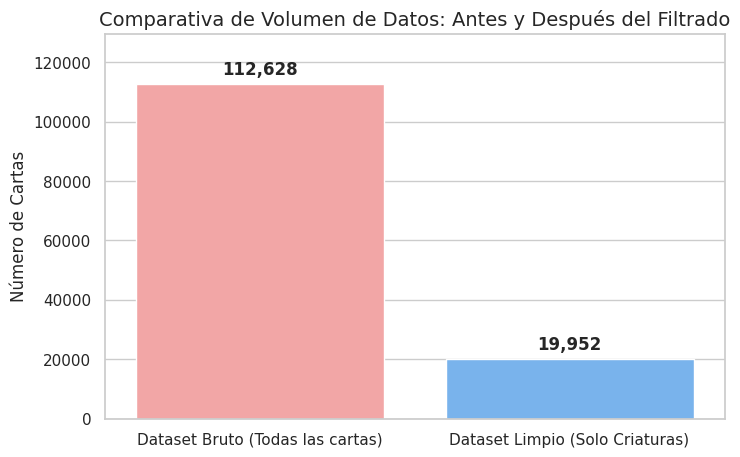

In [38]:
# 1. Guardamos el tamaño original
total_bruto = len(df)

# 2. Aplicamos el Filtro 1: Solo Criaturas
df_c = df[df['type_line'].str.contains('Creature', na=False)].copy()

# 3. Aplicamos el Filtro 2: Excluir estadísticas variables (* o +)
df_c = df_c[~df_c['power'].astype(str).str.contains(r'\*|\+', na=False)]
df_c = df_c[~df_c['toughness'].astype(str).str.contains(r'\*|\+', na=False)]

# 4. Aplicamos el Filtro 3: Solo sets principales (Expansiones y Core sets)
# Scryfall clasifica los sets normales como 'core', 'expansion', o 'draft_innovation'
sets_permitidos = ['core', 'expansion']
df_c = df_c[df_c['set_type'].isin(sets_permitidos)].copy()

total_limpio = len(df_c)
cartas_descartadas = total_bruto - total_limpio

print(f"Cartas en el dataset bruto: {total_bruto}")
print(f"Cartas tras aplicar los filtros (Solo Criaturas Estándar): {total_limpio}")
print(f"Cartas descartadas: {cartas_descartadas}")

# --- VISUALIZACIÓN DE LA LIMPIEZA ---
plt.figure(figsize=(8, 5))

# Creamos un gráfico de barras para comparar
sns.barplot(
    x=['Dataset Bruto (Todas las cartas)', 'Dataset Limpio (Solo Criaturas)'],
    y=[total_bruto, total_limpio],
    palette=['#ff9999', '#66b3ff']
)

plt.title('Comparativa de Volumen de Datos: Antes y Después del Filtrado', fontsize=14)
plt.ylabel('Número de Cartas')

# Añadimos las etiquetas con los números exactos encima de las barras
plt.text(0, total_bruto + 2000, f"{total_bruto:,}", ha='center', va='bottom', fontweight='bold')
plt.text(1, total_limpio + 2000, f"{total_limpio:,}", ha='center', va='bottom', fontweight='bold')

plt.ylim(0, total_bruto * 1.15) # Damos un poco de margen por arriba
plt.show()

## 5. Separación de Datos
Es importante dividir el conjunto de datos original en dos subgrupos independientes. En Scikit-learn se usa *train_test_split*


Si evaluamos el modelo con los mismos datos que usamos para entrenarlo no sabra como se comportará ante datos del ¨mundo real¨ que nunca ha visto. A esto lo llamamos **Overfitting**

Training Set : Es la proporción de datos que se entrega al algoritmo

Test set: Es una porcoón de datos que se mantiene oculta al modelo durante el entrenamiento. Se usa para medir la precisión real del modelo.

### 5.2 Predicción

In [45]:
# --- EJEMPLO DE PREDICCIÓN CON UNA CARTA NUEVA ---
print("\nEjemplo de predicción para una carta inventada (Fuerza 5, Resistencia 5, Coste 4, Rara):")
# Creamos una carta con: cmc=4, power=5, toughness=5, rarity=2 (Rara), text_len=100, color_count=1
carta_nueva = pd.DataFrame([[4, 5, 5, 2, 100, 1]], columns=features)

# La escalamos usando el scaler que ya habíamos entrenado
carta_nueva_scaled = scaler.transform(carta_nueva)

# Predecimos su precio
precio_predicho = modelo_mtg.predict(carta_nueva_scaled)
print(f"El modelo estima que esta carta valdría: {precio_predicho[0]:.2f} USD")


Ejemplo de predicción para una carta inventada (Fuerza 5, Resistencia 5, Coste 4, Rara):
El modelo estima que esta carta valdría: 0.61 USD


## 6. Exploración de Datos (EDA)

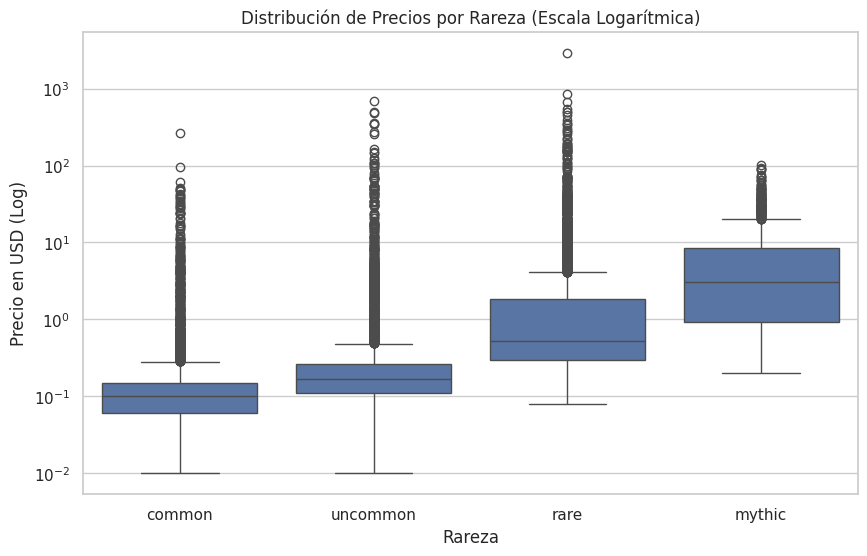

In [39]:
# Configuramos el estilo de las gráficas
sns.set_theme(style="whitegrid")

# Filtramos solo criaturas para los gráficos y extraemos el precio
df_c['target_price'] = pd.to_numeric(df_c['prices'].apply(lambda x: x.get('usd')), errors='coerce')
df_c = df_c.dropna(subset=['target_price'])

# BOXPLOT: Identificación de Outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x='rarity', y='target_price', data=df_c, order=['common', 'uncommon', 'rare', 'mythic'])
plt.title('Distribución de Precios por Rareza (Escala Logarítmica)')
plt.ylabel('Precio en USD (Log)')
plt.xlabel('Rareza')
plt.yscale('log') # Escala logarítmica por los precios extremos
plt.show()

## 7. Desarrollo y Optimización del Modelo

### 7.1 Primera Iteración: Modelo Base (Naïve)
En Ciencia de Datos, es una buena práctica entrenar primero un "Modelo Base" utilizando todos los datos disponibles sin filtrar, para establecer un punto de partida. A continuación, procesamos el dataset completo, incluyendo las cartas de valores extremos (outliers).


Ahora que tenemos los datos divididos, debemos explicar que transformaciones aplicamos antess de pasarlos por el modelo. Scikit-learn requiere que todos los datos de entrada sean numéricos y estén limpios.

Técnicas que debemos incluir en nustro Dataset:


*   Data Cleaning <br>
    Muchas cartas no tienen fuerza o resistencia (como las cartas de Conjuro)
*   Label Encoding <br>
  variable objetivo. Precio.

*   Feature Scaling <br>
  Modificar el rango de las variables para que coincidan entre los diferentes tipos
  



In [40]:
# --- MODELO BASE (CON TODOS LOS DATOS Y OUTLIERS) ---

# 1. Preparación de variables numéricas
df_base = df_c.copy()
df_base['power_num'] = pd.to_numeric(df_base['power'], errors='coerce')
df_base['toughness_num'] = pd.to_numeric(df_base['toughness'], errors='coerce')
df_base['color_count'] = df_base['colors'].apply(lambda x: len(x) if isinstance(x, list) else 0)
df_base['text_len'] = df_base['oracle_text'].apply(lambda x: len(str(x)) if x else 0)
df_base['rarity_num'] = df_base['rarity'].map({'common': 0, 'uncommon': 1, 'rare': 2, 'mythic': 3}).fillna(0)

# 2. Definición de X e y (Usando TODAS las cartas, sin límite de precio)
features = ['cmc', 'power_num', 'toughness_num', 'rarity_num', 'text_len', 'color_count']
X_base = df_base[features].copy()
y_base = df_base['target_price'].copy()

# 3. Imputación de nulos y Separación (Train/Test)
imputador = SimpleImputer(strategy='constant', fill_value=0)
X_base[['power_num', 'toughness_num']] = imputador.fit_transform(X_base[['power_num', 'toughness_num']])

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_base, y_base, test_size=0.2, random_state=42)

# 4. Escalado y Entrenamiento
scaler_b = StandardScaler()
X_train_b_scaled = scaler_b.fit_transform(X_train_b)
X_test_b_scaled = scaler_b.transform(X_test_b)

modelo_base = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_base.fit(X_train_b_scaled, y_train_b)

# 5. Evaluación
y_pred_b = modelo_base.predict(X_test_b_scaled)
print(f"--- RESULTADOS MODELO BASE (Con Outliers) ---")
print(f"MAE: {mean_absolute_error(y_test_b, y_pred_b):.2f} USD")
print(f"R2: {r2_score(y_test_b, y_pred_b):.2f}")

--- RESULTADOS MODELO BASE (Con Outliers) ---
MAE: 3.25 USD
R2: -0.01


### 7.2 Diagnóstico y Segunda Iteración: Modelo Optimizado
Como se puede observar, el **Modelo Base fracasa**, obteniendo un $R^2$ negativo y un error alto. Esto se debe a que el algoritmo *Random Forest* intenta no equivocarse en las cartas de coleccionista de más de 100$ (los outliers que vimos en el Boxplot), distorsionando las predicciones de las cartas normales.

Para solucionarlo, aplicamos un "recorte de dominio", limitando el entrenamiento al mercado de juego estándar (cartas de $\le$ 30 USD).

In [41]:
# --- MODELO OPTIMIZADO (FILTRANDO OUTLIERS <= 30$) ---

# 1. Filtramos las cartas muy caras (El recorte de dominio)
df_modelo = df_c[df_c['target_price'] <= 30.0].copy()

# 2. Creamos las mismas variables numéricas
df_modelo['power_num'] = pd.to_numeric(df_modelo['power'], errors='coerce')
df_modelo['toughness_num'] = pd.to_numeric(df_modelo['toughness'], errors='coerce')
df_modelo['color_count'] = df_modelo['colors'].apply(lambda x: len(x) if isinstance(x, list) else 0)
df_modelo['text_len'] = df_modelo['oracle_text'].apply(lambda x: len(str(x)) if x else 0)
df_modelo['rarity_num'] = df_modelo['rarity'].map({'common': 0, 'uncommon': 1, 'rare': 2, 'mythic': 3}).fillna(0)

# 3. Definimos X e Y
X = df_modelo[features].copy()
y = df_modelo['target_price'].copy()

# 4. Rellenamos nulos, separamos y escalamos
X[['power_num', 'toughness_num']] = imputador.transform(X[['power_num', 'toughness_num']])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Entrenamos el nuevo modelo optimizado
modelo_mtg = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_mtg.fit(X_train_scaled, y_train)

# 6. Evaluación
y_pred = modelo_mtg.predict(X_test_scaled)
print(f"--- RESULTADOS MODELO OPTIMIZADO (Cartas <= 30$) ---")
print(f"Nuevo MAE: {mean_absolute_error(y_test, y_pred):.2f} USD")
print(f"Nuevo R2: {r2_score(y_test, y_pred):.2f}")

--- RESULTADOS MODELO OPTIMIZADO (Cartas <= 30$) ---
Nuevo MAE: 1.11 USD
Nuevo R2: 0.19


### 7.3 Comparativa Visual de los Modelos
Para poner en perspectiva el impacto de nuestra limpieza de datos y del recorte de dominio (eliminar cartas > 30$), vamos a comparar visualmente las métricas del Modelo Base frente a las del Modelo Optimizado.

Como veremos, el Error Absoluto Medio (MAE) se desploma, y el Coeficiente de Determinación ($R^2$) pasa de ser negativo (un modelo inservible) a un valor positivo, demostrando que el algoritmo por fin ha captado la relación subyacente entre las mecánicas de la carta y su precio.

/tmp/ipykernel_403/427933102.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Modelo Base\n(Todos los datos)', 'Modelo Optimizado\n(Cartas <= 30$)'],
/tmp/ipykernel_403/427933102.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Modelo Base\n(Todos los datos)', 'Modelo Optimizado\n(Cartas <= 30$)'],


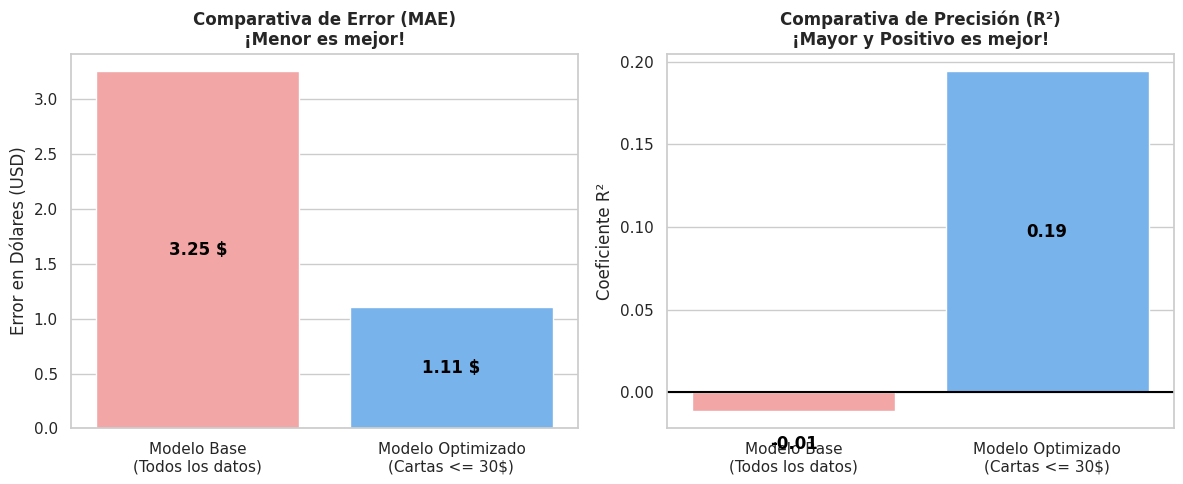

In [42]:
# 1. Calculamos las métricas exactas basándonos en las predicciones anteriores
mae_base = mean_absolute_error(y_test_b, y_pred_b)
r2_base = r2_score(y_test_b, y_pred_b)

mae_opt = mean_absolute_error(y_test, y_pred)
r2_opt = r2_score(y_test, y_pred)

# 2. Preparamos la figura con 2 subgráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Gráfico 1: Comparativa de MAE (Menos es mejor) ---
sns.barplot(x=['Modelo Base\n(Todos los datos)', 'Modelo Optimizado\n(Cartas <= 30$)'],
            y=[mae_base, mae_opt], palette=['#ff9999', '#66b3ff'], ax=axes[0])
axes[0].set_title('Comparativa de Error (MAE)\n¡Menor es mejor!', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Error en Dólares (USD)')

# Ponemos el numerito dentro de la barra para que quede profesional
axes[0].text(0, mae_base / 2, f"{mae_base:.2f} $", ha='center', va='center', fontweight='bold', fontsize=12, color='black')
axes[0].text(1, mae_opt / 2, f"{mae_opt:.2f} $", ha='center', va='center', fontweight='bold', fontsize=12, color='black')

# --- Gráfico 2: Comparativa de R2 (Más cerca de 1 es mejor) ---
sns.barplot(x=['Modelo Base\n(Todos los datos)', 'Modelo Optimizado\n(Cartas <= 30$)'],
            y=[r2_base, r2_opt], palette=['#ff9999', '#66b3ff'], ax=axes[1])
axes[1].set_title('Comparativa de Precisión (R²)\n¡Mayor y Positivo es mejor!', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Coeficiente R²')

# Dibujamos una línea negra en el 0 para que se vea claro el valor negativo del primer modelo
axes[1].axhline(0, color='black', linewidth=1.5)

# Ajustamos la posición del texto (si es negativo, va un poco más abajo del 0)
pos_r2_base = r2_base - 0.02 if r2_base < 0 else r2_base / 2
axes[1].text(0, pos_r2_base, f"{r2_base:.2f}", ha='center', va='center', fontweight='bold', fontsize=12, color='black')
axes[1].text(1, r2_opt / 2, f"{r2_opt:.2f}", ha='center', va='center', fontweight='bold', fontsize=12, color='black')

plt.tight_layout()
plt.show()

## 8. Visualización de Resultados
Usaremos un Gráfico de Dispersión "Scatter Plot" que compara los precios reales frente a los predichos

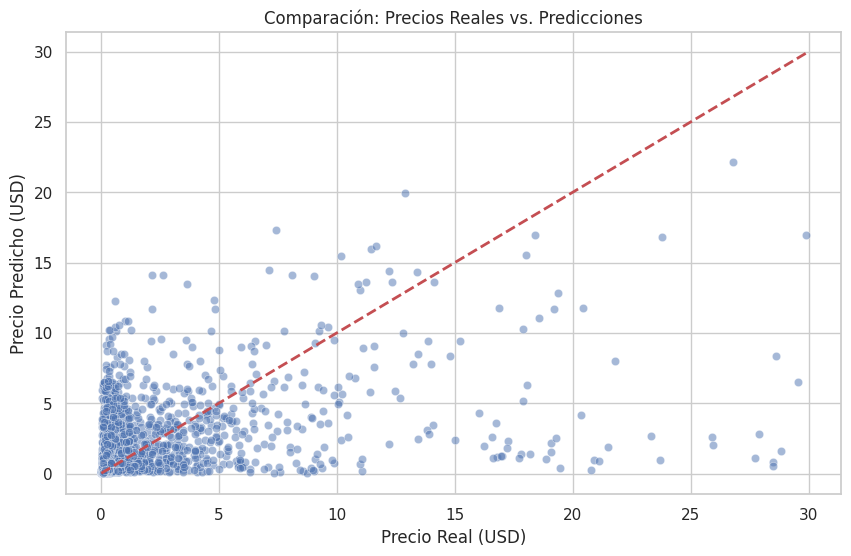

In [43]:


plt.figure(figsize=(10, 6))

# Creamos el gráfico de dispersión
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)

# Añadimos una línea ideal (donde Real == Predicho)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)

plt.title('Comparación: Precios Reales vs. Predicciones')
plt.xlabel('Precio Real (USD)')
plt.ylabel('Precio Predicho (USD)')
plt.grid(True)
plt.show()

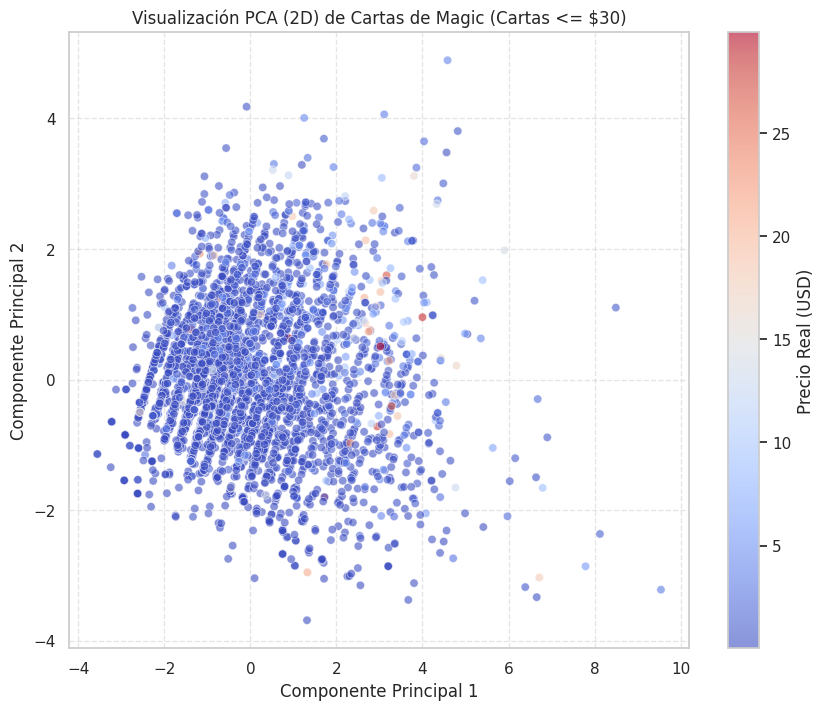

In [44]:


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_test, cmap='coolwarm', alpha=0.6, edgecolors='w', linewidth=0.5)

cbar = plt.colorbar(scatter)
cbar.set_label('Precio Real (USD)')

plt.title('Visualización PCA (2D) de Cartas de Magic (Cartas <= $30)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

## 9. Conclusión

# Buscamos si el texto contiene ciertas palabras clave (1 si lo tiene, 0 si no)
df_modelo['has_flying'] = df_modelo['oracle_text'].str.contains('Flying', case=False, na=False).astype(int)
df_modelo['has_trample'] = df_modelo['oracle_text'].str.contains('Trample', case=False, na=False).astype(int)
df_modelo['has_haste'] = df_modelo['oracle_text'].str.contains('Haste', case=False, na=False).astype(int)

# Y luego simplemente actualizarías tu lista de features:
features = ['cmc', 'power_num', 'toughness_num', 'rarity_num', 'text_len', 'color_count',
            'has_flying', 'has_trample', 'has_haste']

## 10. Bibliografía
* **Scikit-learn Developers. (s.f.).** *User Guide*. Recuperado de https://scikit-learn.org/stable/user_guide.html
* **Scikit-learn Developers. (s.f.).** *Importance of Feature Scaling*. Recuperado de https://scikit-learn.org/stable/auto_examples/preprocessing/plot_scaling_importance.html
* **Pandas Development Team. (s.f.).** *Intro to Data Structures*. Recuperado de https://pandas.pydata.org/docs/user_guide/dsintro.html
* **Scryfall. (2024).** *Scryfall API Documentation: Bulk Data*. Recuperado de https://scryfall.com/docs/api/bulk-data
* **Géron, A. (2019).** *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (2nd ed.). O'Reilly Media. (Justificación del tratamiento de outliers).
* **Waskom, M. L. (2021).** *seaborn: statistical data visualization*. Journal of Open Source Software, 6(60), 3021. https://doi.org/10.21105/joss.03021
* **Reitz, K. (2024).** *Requests: HTTP for Humans*. Recuperado de https://requests.readthedocs.io/